In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from pathlib import Path

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.20.0
Keras: 3.13.2
NumPy: 2.1.3


In [2]:
physical_devices = tf.config.list_physical_devices("GPU")
print("GPU devices:", physical_devices)

if physical_devices:
    print("GPU acceleration is available.")
else:
    print("Running on CPU.")

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU acceleration is available.


In [3]:
from keras.applications import ResNet50

resnet50 = ResNet50(
    weights="imagenet",
    include_top=True
)

print("Model loaded successfully.")

Model loaded successfully.


In [4]:
resnet50.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 25,636,712 (97.80 MB)

 Trainable params: 25,583,592 (97.59 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [5]:
print("Input shape:", resnet50.input_shape)
print("Output shape:", resnet50.output_shape)
print("Total parameters:", resnet50.count_params())

Input shape: (None, 224, 224, 3)
Output shape: (None, 1000)
Total parameters: 25636712


In [6]:
trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in resnet50.trainable_variables
])

non_trainable_params = np.sum([
    np.prod(variable.shape)
    for variable in resnet50.non_trainable_variables
])

print("Trainable parameters:", int(trainable_params))
print("Non-trainable parameters:", int(non_trainable_params))

Trainable parameters: 25583592
Non-trainable parameters: 53120


In [7]:
layer_records = []

for index, layer in enumerate(resnet50.layers):
    layer_records.append({
        "index": index,
        "name": layer.name,
        "type": layer.__class__.__name__,
        "output_shape": str(layer.output.shape)
    })

layers_df = pd.DataFrame(layer_records)

display(layers_df.head(25))

,index,name,type,output_shape
0,0,input_layer,InputLayer,"(None, 224, 224, 3)"
1,1,conv1_pad,ZeroPadding2D,"(None, 230, 230, 3)"
2,2,conv1_conv,Conv2D,"(None, 112, 112, 64)"
3,3,conv1_bn,BatchNormalization,"(None, 112, 112, 64)"
4,4,conv1_relu,Activation,"(None, 112, 112, 64)"
5,5,pool1_pad,ZeroPadding2D,"(None, 114, 114, 64)"
6,6,pool1_pool,MaxPooling2D,"(None, 56, 56, 64)"
7,7,conv2_block1_1_conv,Conv2D,"(None, 56, 56, 64)"
8,8,conv2_block1_1_bn,BatchNormalization,"(None, 56, 56, 64)"
9,9,conv2_block1_1_relu,Activation,"(None, 56, 56, 64)"


In [8]:
layers_df.tail(15)

,index,name,type,output_shape
162,162,conv5_block2_3_bn,BatchNormalization,"(None, 7, 7, 2048)"
163,163,conv5_block2_add,Add,"(None, 7, 7, 2048)"
164,164,conv5_block2_out,Activation,"(None, 7, 7, 2048)"
165,165,conv5_block3_1_conv,Conv2D,"(None, 7, 7, 512)"
166,166,conv5_block3_1_bn,BatchNormalization,"(None, 7, 7, 512)"
167,167,conv5_block3_1_relu,Activation,"(None, 7, 7, 512)"
168,168,conv5_block3_2_conv,Conv2D,"(None, 7, 7, 512)"
169,169,conv5_block3_2_bn,BatchNormalization,"(None, 7, 7, 512)"
170,170,conv5_block3_2_relu,Activation,"(None, 7, 7, 512)"
171,171,conv5_block3_3_conv,Conv2D,"(None, 7, 7, 2048)"


In [9]:
IMAGE_PATH = None

In [10]:
try:
    from google.colab import files

    uploaded = files.upload()

    if uploaded:
        IMAGE_PATH = next(iter(uploaded.keys()))
        print("Selected:", IMAGE_PATH)
except ImportError:
    print("Local Jupyter detected.")
    print("Set IMAGE_PATH manually before running the prediction cells.")

Saving humans.jpg to humans (1).jpg
Selected: humans (1).jpg


In [11]:
if IMAGE_PATH is None:
    print("No image selected yet.")
else:
    print("Image:", IMAGE_PATH)
    print("Exists:", Path(IMAGE_PATH).exists())

Image: humans (1).jpg
Exists: True


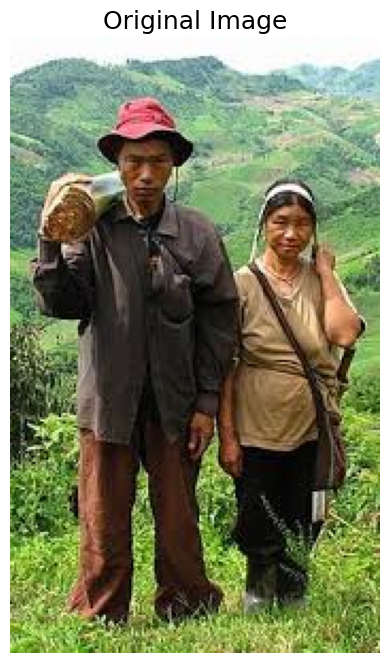

In [12]:
from keras.utils import load_img, img_to_array

if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    original_image = load_img(IMAGE_PATH)
    plt.figure(figsize=(8, 8))
    plt.imshow(original_image)
    plt.axis("off")
    plt.title("Original Image", fontsize=18)
    plt.show()
else:
    print("Please provide a valid IMAGE_PATH.")

In [13]:
TARGET_SIZE = (224, 224)

if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    image = load_img(
        IMAGE_PATH,
        target_size=TARGET_SIZE
    )

    image_array = img_to_array(image)

    print("Array shape:", image_array.shape)
    print("Data type:", image_array.dtype)
    print("Minimum pixel:", image_array.min())
    print("Maximum pixel:", image_array.max())

Array shape: (224, 224, 3)
Data type: float32
Minimum pixel: 0.0
Maximum pixel: 255.0


In [14]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    image_batch = np.expand_dims(image_array, axis=0)

    print("Single image:", image_array.shape)
    print("Batch:", image_batch.shape)

Single image: (224, 224, 3)
Batch: (1, 224, 224, 3)


In [15]:
from keras.applications.resnet import preprocess_input

if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    preprocessed_batch = preprocess_input(image_batch.copy())

    print("Original range:", (image_batch.min(), image_batch.max()))
    print("Processed range:", (preprocessed_batch.min(), preprocessed_batch.max()))
    print("Processed shape:", preprocessed_batch.shape)

Original range: (np.float32(0.0), np.float32(255.0))
Processed range: (np.float32(-123.68), np.float32(151.061))
Processed shape: (1, 224, 224, 3)


In [16]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    predictions = resnet50.predict(
        preprocessed_batch,
        verbose=0
    )

    print("Prediction tensor shape:", predictions.shape)

Prediction tensor shape: (1, 1000)


In [17]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    print("Number of outputs:", predictions.shape[-1])
    print("First 10 raw probabilities:")
    print(predictions[0][:10])
    print("Probability sum:", predictions[0].sum())

Number of outputs: 1000
First 10 raw probabilities:
[3.8631767e-02 4.6917876e-06 1.5653603e-04 1.1844662e-03 9.8636537e-04
 1.7472217e-03 3.5257742e-04 1.6800688e-04 8.1749014e-05 8.4257260e-04]
Probability sum: 1.0


In [18]:
from keras.applications.resnet import decode_predictions

if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    decoded_predictions = decode_predictions(
        predictions,
        top=10
    )[0]

    decoded_predictions

In [19]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    prediction_df = pd.DataFrame(
        decoded_predictions,
        columns=["class_id", "class_name", "probability"]
    )

    prediction_df["probability_percent"] = (
        prediction_df["probability"] * 100
    )

    prediction_df

In [20]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    top1 = prediction_df.iloc[0]

    print("Top-1 class:", top1["class_name"])
    print("Class ID:", top1["class_id"])
    print(f"Confidence: {top1['probability']:.4f}")
    print(f"Confidence %: {top1['probability'] * 100:.2f}%")

Top-1 class: half_track
Class ID: n03478589
Confidence: 0.1868
Confidence %: 18.68%


In [21]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    top5_df = prediction_df.head(5).copy()
    top5_df

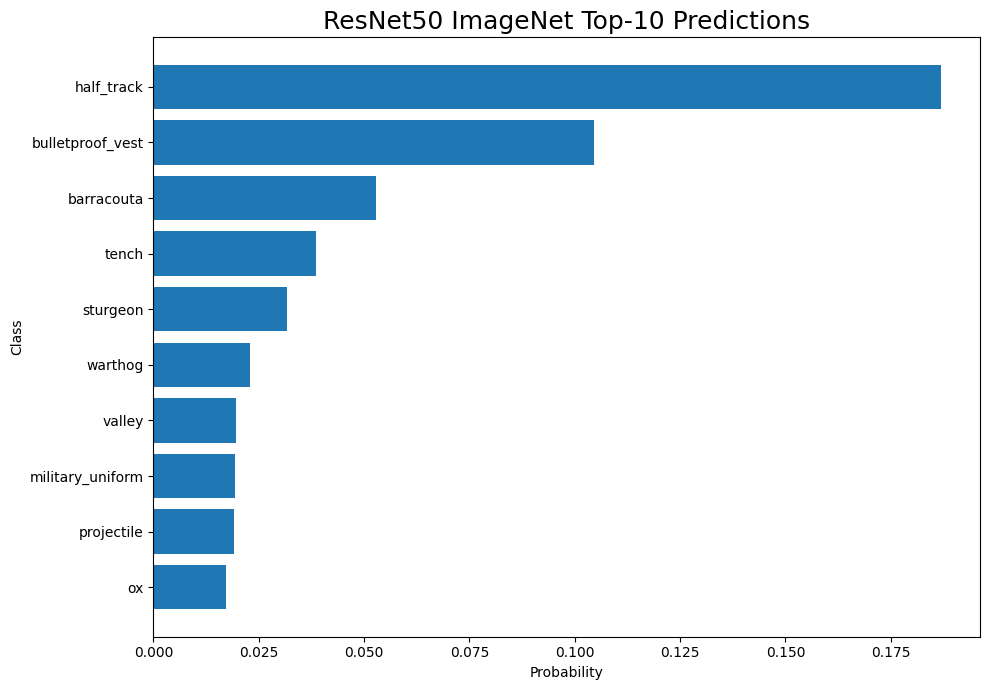

In [22]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    plot_df = prediction_df.sort_values(
        "probability",
        ascending=True
    )

    plt.figure(figsize=(10, 7))
    plt.barh(
        plot_df["class_name"],
        plot_df["probability"]
    )
    plt.xlabel("Probability")
    plt.ylabel("Class")
    plt.title("ResNet50 ImageNet Top-10 Predictions", fontsize=18)
    plt.tight_layout()
    plt.show()

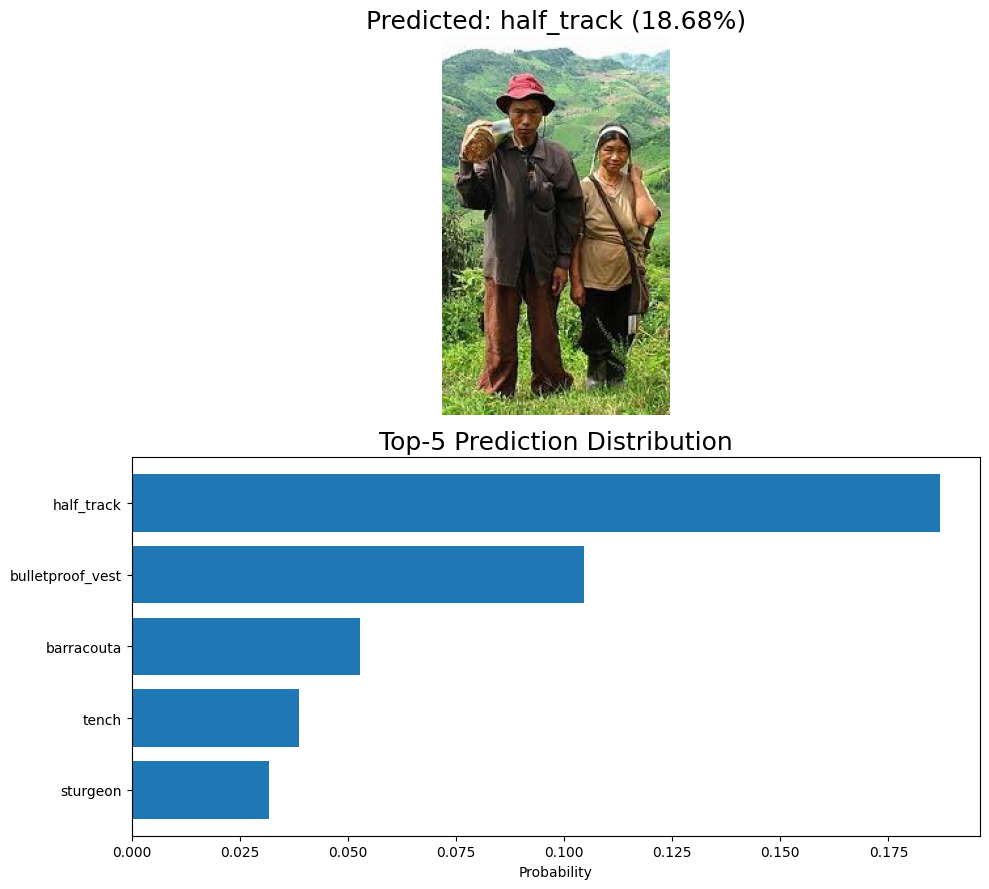

In [23]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    plt.figure(figsize=(10, 9))

    plt.subplot(2, 1, 1)
    plt.imshow(load_img(IMAGE_PATH))
    plt.axis("off")
    plt.title(
        f"Predicted: {top1['class_name']} "
        f"({top1['probability'] * 100:.2f}%)",
        fontsize=18
    )

    plt.subplot(2, 1, 2)
    plt.barh(
        prediction_df["class_name"].head(5)[::-1],
        prediction_df["probability"].head(5)[::-1]
    )
    plt.xlabel("Probability")
    plt.title("Top-5 Prediction Distribution", fontsize=18)

    plt.tight_layout()
    plt.show()

In [24]:
def predict_image(
    model,
    image_path,
    target_size=(224, 224),
    top_k=5
):
    image = load_img(
        image_path,
        target_size=target_size
    )

    array = img_to_array(image)
    batch = np.expand_dims(array, axis=0)
    batch = preprocess_input(batch.copy())

    predictions = model.predict(
        batch,
        verbose=0
    )

    decoded = decode_predictions(
        predictions,
        top=top_k
    )[0]

    result = pd.DataFrame(
        decoded,
        columns=["class_id", "class_name", "probability"]
    )

    result["probability_percent"] = (
        result["probability"] * 100
    )

    return image, result

In [25]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    predicted_image, result = predict_image(
        resnet50,
        IMAGE_PATH,
        top_k=10
    )

    result

In [26]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    best_prediction = result.iloc[0]

    print(
        f"{best_prediction['class_name']} — "
        f"{best_prediction['probability_percent']:.2f}%"
    )

half_track — 18.68%


In [27]:
IMAGE_PATHS = ["humans.jpg","cats.jpg"]

print("Add image paths here, for example:")
print([
    "image1.jpg",
    "image2.jpg",
    "image3.jpg"
])

Add image paths here, for example:
['image1.jpg', 'image2.jpg', 'image3.jpg']


In [28]:
def prepare_resnet_batch(
    image_paths,
    target_size=(224, 224)
):
    images = []
    display_images = []

    for path in image_paths:
        image = load_img(
            path,
            target_size=target_size
        )

        array = img_to_array(image)
        images.append(array)
        display_images.append(image)

    batch = np.stack(images, axis=0)
    batch = preprocess_input(batch.copy())

    return batch, display_images

In [29]:
if IMAGE_PATHS:
    valid_paths = [
        path for path in IMAGE_PATHS
        if Path(path).exists()
    ]

    print("Valid images:", len(valid_paths))

    if valid_paths:
        batch, display_images = prepare_resnet_batch(valid_paths)
        batch_predictions = resnet50.predict(
            batch,
            verbose=0
        )

        batch_decoded = decode_predictions(
            batch_predictions,
            top=5
        )

Valid images: 2


In [30]:
if IMAGE_PATHS and valid_paths:
    batch_rows = []

    for path, decoded in zip(valid_paths, batch_decoded):
        first_prediction = decoded[0]

        batch_rows.append({
            "image": Path(path).name,
            "prediction": first_prediction[1],
            "confidence": first_prediction[2],
            "confidence_percent": first_prediction[2] * 100
        })

    batch_results_df = pd.DataFrame(batch_rows)
    batch_results_df

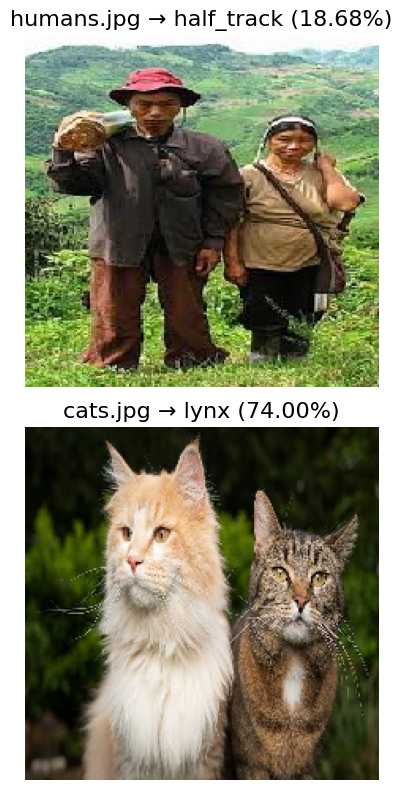

In [31]:
if IMAGE_PATHS and valid_paths:
    n = len(valid_paths)

    fig, axes = plt.subplots(
        n,
        1,
        figsize=(12, max(5, n * 4))
    )

    if n == 1:
        axes = [axes]

    for axis, image, decoded, path in zip(
        axes,
        display_images,
        batch_decoded,
        valid_paths
    ):
        top_prediction = decoded[0]

        axis.imshow(image)
        axis.axis("off")
        axis.set_title(
            f"{Path(path).name} → "
            f"{top_prediction[1]} "
            f"({top_prediction[2] * 100:.2f}%)",
            fontsize=16
        )

    plt.tight_layout()
    plt.show()

In [32]:
weights_snapshot = {
    "layers": len(resnet50.layers),
    "parameters": resnet50.count_params(),
    "input_shape": resnet50.input_shape,
    "output_shape": resnet50.output_shape
}

pd.Series(weights_snapshot)

,0
layers,177
parameters,25636712
input_shape,"(None, 224, 224, 3)"
output_shape,"(None, 1000)"


In [33]:
resnet50_features = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("Feature extractor loaded.")
print("Input shape:", resnet50_features.input_shape)
print("Output shape:", resnet50_features.output_shape)
print("Parameters:", resnet50_features.count_params())

Feature extractor loaded.
Input shape: (None, None, None, 3)
Output shape: (None, 2048)
Parameters: 23587712


In [34]:
comparison = pd.DataFrame({
    "mode": [
        "ImageNet classifier",
        "Feature extractor"
    ],
    "include_top": [
        True,
        False
    ],
    "pooling": [
        None,
        "avg"
    ],
    "use_case": [
        "ImageNet prediction",
        "Feature extraction / transfer learning"
    ]
})

comparison

,mode,include_top,pooling,use_case
0,ImageNet classifier,True,None,ImageNet prediction
1,Feature extractor,False,avg,Feature extraction / transfer learning


In [35]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    feature_batch = preprocess_input(
        image_batch.copy()
    )

    features = resnet50_features.predict(
        feature_batch,
        verbose=0
    )

    print("Feature shape:", features.shape)

Feature shape: (1, 2048)


In [36]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    feature_vector = features[0]

    print("Feature vector length:", feature_vector.shape[0])
    print("First 20 features:")
    print(feature_vector[:20])


Feature vector length: 2048
First 20 features:
[0.04236678 1.3774614  0.38812745 0.23629534 0.21617769 0.61686283
 0.00284382 0.14075734 0.         0.34422216 0.66693455 0.05730665
 0.9175752  0.1662228  0.0672684  0.44213107 0.03201347 0.05460187
 0.35270765 0.92808664]


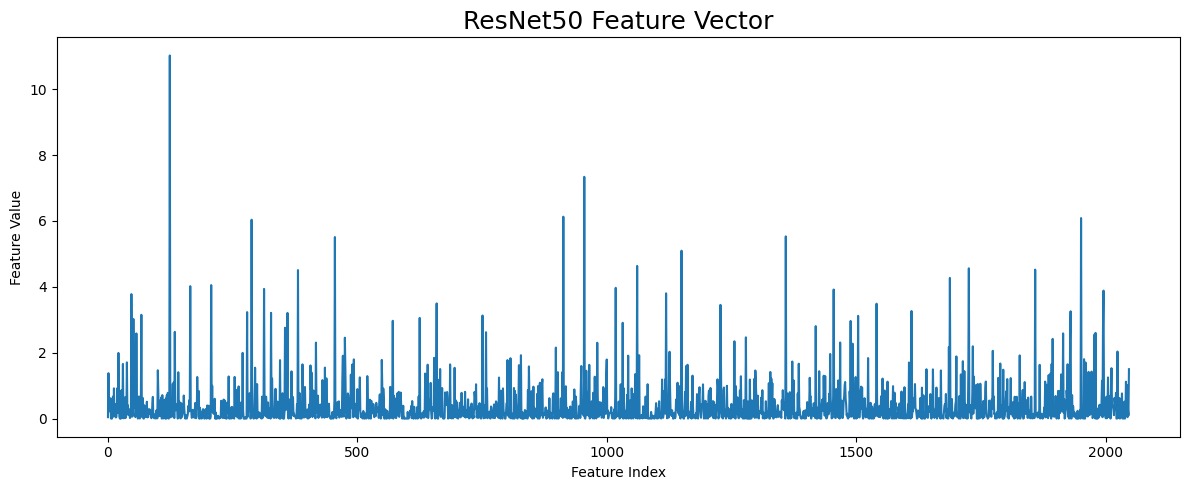

In [37]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    feature_vector = features[0]

    plt.figure(figsize=(12, 5))
    plt.plot(np.arange(len(feature_vector)), feature_vector)
    plt.xlabel("Feature Index")
    plt.ylabel("Feature Value")
    plt.title("ResNet50 Feature Vector", fontsize=18)
    plt.tight_layout()
    plt.show()


In [38]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    np.save(
        "resnet50_features.npy",
        features
    )

    print("Saved:", Path("resnet50_features.npy").resolve())

Saved: /content/resnet50_features.npy


In [39]:
FEATURE_IMAGE_DIR = Path("images")

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

folder_images = [
    path for path in FEATURE_IMAGE_DIR.iterdir()
    if path.suffix.lower() in image_extensions
] if FEATURE_IMAGE_DIR.exists() else []

print("Images found:", len(folder_images))

Images found: 0


In [40]:
def extract_features_from_paths(
    model,
    paths,
    target_size=(224, 224),
    batch_size=32
):
    all_features = []
    valid_paths = []

    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start:start + batch_size]
        batch_arrays = []

        for path in batch_paths:
            image = load_img(
                path,
                target_size=target_size
            )
            array = img_to_array(image)
            batch_arrays.append(array)

        batch_arrays = np.stack(
            batch_arrays,
            axis=0
        )

        batch_arrays = preprocess_input(
            batch_arrays.copy()
        )

        batch_features = model.predict(
            batch_arrays,
            verbose=0
        )

        all_features.append(batch_features)
        valid_paths.extend(batch_paths)

    if not all_features:
        return np.empty((0, 2048)), []

    return np.concatenate(all_features, axis=0), valid_paths

In [41]:
if folder_images:
    folder_features, feature_paths = extract_features_from_paths(
        resnet50_features,
        folder_images
    )

    print("Feature matrix:", folder_features.shape)
    print("Number of images:", len(feature_paths))


In [42]:
from keras.applications import (
    VGG16,
    MobileNetV2,
    EfficientNetB0
)

model_options = pd.DataFrame([
    {
        "model": "ResNet50",
        "input_size": "224×224",
        "preprocessing": "keras.applications.resnet.preprocess_input"
    },
    {
        "model": "VGG16",
        "input_size": "224×224",
        "preprocessing": "keras.applications.vgg16.preprocess_input"
    },
    {
        "model": "MobileNetV2",
        "input_size": "224×224",
        "preprocessing": "keras.applications.mobilenet_v2.preprocess_input"
    },
    {
        "model": "EfficientNetB0",
        "input_size": "224×224",
        "preprocessing": "integrated preprocessing in current Keras implementation"
    }
])

model_options

,model,input_size,preprocessing
0,ResNet50,224×224,keras.applications.resnet.preprocess_input
1,VGG16,224×224,keras.applications.vgg16.preprocess_input
2,MobileNetV2,224×224,keras.applications.mobilenet_v2.preprocess_input
3,EfficientNetB0,224×224,integrated preprocessing in current Keras impl...


In [43]:
conv_layers = [
    layer for layer in resnet50.layers
    if isinstance(layer, keras.layers.Conv2D)
]

print("Convolutional layers found:", len(conv_layers))

first_conv = conv_layers[0]

print("First convolution layer:", first_conv.name)
print("Kernel shape:", first_conv.kernel.shape)

Convolutional layers found: 53
First convolution layer: conv1_conv
Kernel shape: (7, 7, 3, 64)


In [44]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    activation_model = keras.Model(
        inputs=resnet50.input,
        outputs=first_conv.output
    )

    first_activation = activation_model.predict(
        preprocessed_batch,
        verbose=0
    )

    print("Activation shape:", first_activation.shape)


Activation shape: (1, 112, 112, 64)


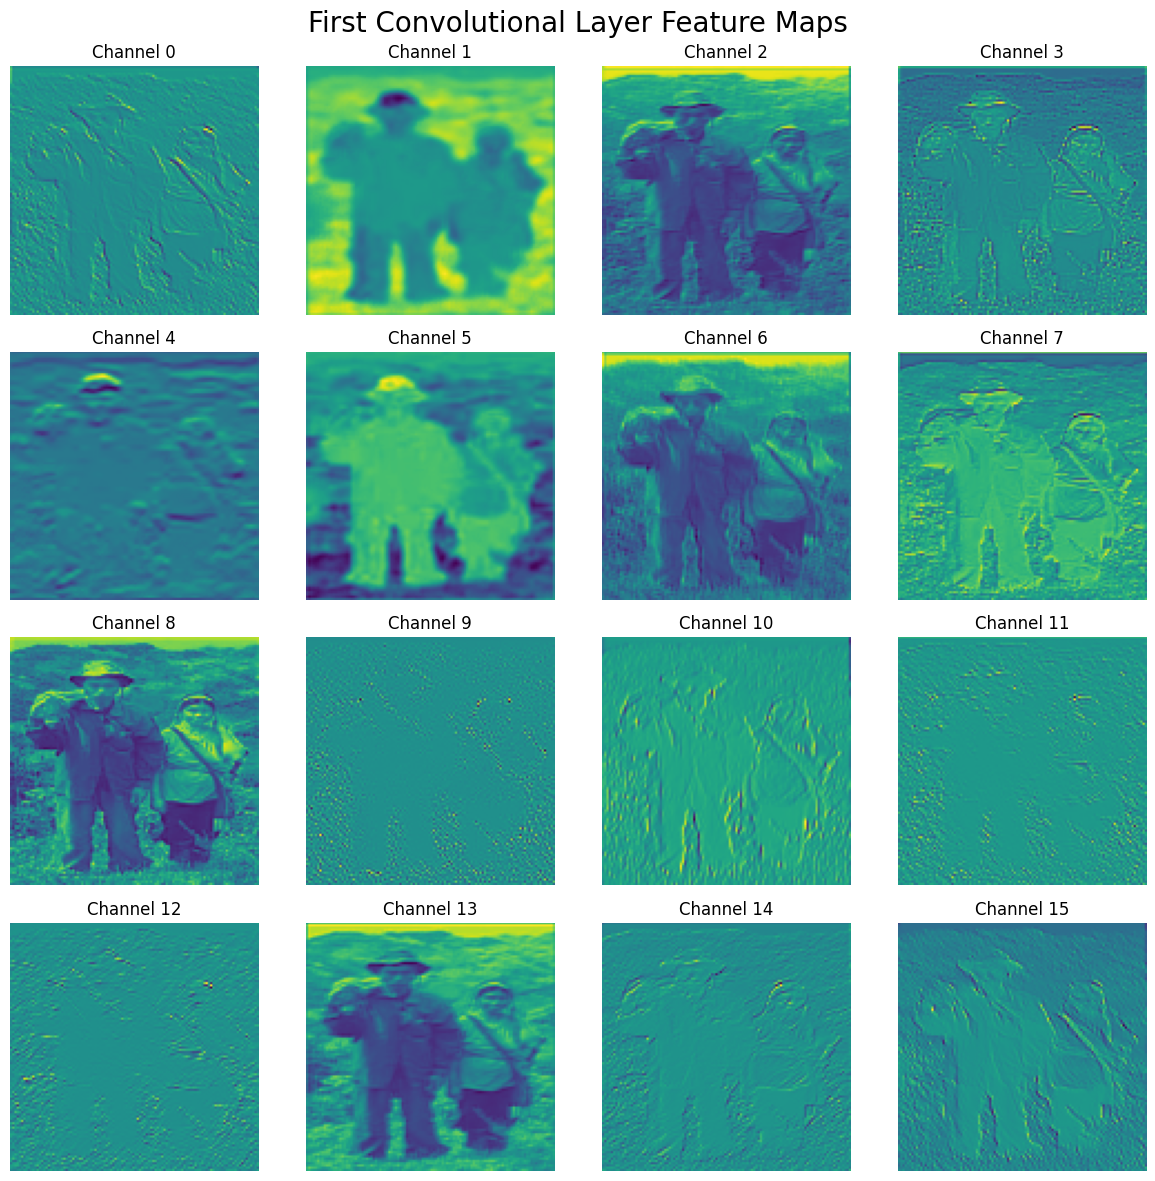

In [45]:
if IMAGE_PATH is not None and Path(IMAGE_PATH).exists():
    activation_maps = first_activation[0]
    n_channels = min(16, activation_maps.shape[-1])

    fig, axes = plt.subplots(
        4,
        4,
        figsize=(12, 12)
    )

    for index, axis in enumerate(axes.ravel()):
        if index < n_channels:
            axis.imshow(
                activation_maps[:, :, index],
                cmap="viridis"
            )
            axis.set_title(f"Channel {index}")
        axis.axis("off")

    plt.suptitle(
        "First Convolutional Layer Feature Maps",
        fontsize=20
    )
    plt.tight_layout()
    plt.show()

In [46]:
base_model = keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = keras.Input(
    shape=(224, 224, 3)
)

x = keras.applications.resnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dropout(0.30)(x)
outputs = keras.layers.Dense(
    2,
    activation="softmax"
)(x)

transfer_model = keras.Model(
    inputs,
    outputs
)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_3[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │      4,098 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [47]:
DATASET_ROOT = Path("dataset")

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "validation"

print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)

Train directory: dataset/train
Validation directory: dataset/validation


In [48]:
if TRAIN_DIR.exists():
    train_ds = keras.utils.image_dataset_from_directory(
        TRAIN_DIR,
        image_size=(224, 224),
        batch_size=32,
        label_mode="int",
        shuffle=True
    )

    print("Training dataset created.")
else:
    print("Create the dataset directory before running this cell.")

Create the dataset directory before running this cell.


In [49]:
if VAL_DIR.exists():
    val_ds = keras.utils.image_dataset_from_directory(
        VAL_DIR,
        image_size=(224, 224),
        batch_size=32,
        label_mode="int",
        shuffle=False
    )

    print("Validation dataset created.")
else:
    print("Create the validation directory before running this cell.")

Create the validation directory before running this cell.


In [50]:
def run_resnet50_inference(
    image_path,
    top_k=5
):
    model = keras.applications.ResNet50(
        weights="imagenet",
        include_top=True
    )

    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    array = img_to_array(image)
    batch = np.expand_dims(array, axis=0)
    batch = keras.applications.resnet.preprocess_input(
        batch.copy()
    )

    predictions = model.predict(
        batch,
        verbose=0
    )

    decoded = keras.applications.resnet.decode_predictions(
        predictions,
        top=top_k
    )[0]

    result = pd.DataFrame(
        decoded,
        columns=[
            "class_id",
            "class_name",
            "probability"
        ]
    )

    result["probability_percent"] = (
        result["probability"] * 100
    )

    return result